**ENVIRONMENT SETUP**

pip install numpy pandas tabulate matplotlib tensorflow scikit-learn imbalanced-learn kagglehub

In [46]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf #Artificial Neural Network
import matplotlib.pyplot as plt
import kagglehub

from tabulate import tabulate
from imblearn.over_sampling import SMOTE
from scikeras.wrappers import KerasClassifier
from sklearn.tree import DecisionTreeClassifier #Decision Tree
from sklearn.ensemble import RandomForestClassifier #Random Forests
from sklearn.linear_model import LogisticRegression #Logistic Regression
from sklearn.model_selection import GridSearchCV #hyperparameters
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

In [47]:
# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# loading the dataset to a Pandas DataFrame
csv_path = os.path.join(path, "creditcard.csv")
credit_card_data = pd.read_csv(csv_path)

Path to dataset files: C:\Users\fazal\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [48]:
# features of dataset
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

The Class feature (30th) is the label of each data entry i.e (0,1) = (Fraudulent,Legit)

In [49]:
# distribution of 'Class'
credit_card_data['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

The distribution of transactions is very unbalanced i.e 284315 fraud vs 492 legit

In [50]:
# splitting into features and target from full dataset
X = credit_card_data.drop(columns='Class', axis=1) #input
Y = credit_card_data['Class'] #output

**Train/Test Data Splits**

In [51]:
# 1) Original imbalanced split (function only, lazy execution)
def build_original_split(X, Y, testRatio=0.2, randomState=42):
    XTrain, XTest, YTrain, YTest = train_test_split(
        X, Y, test_size=testRatio, stratify=Y, random_state=randomState
    )
    return XTrain, XTest, YTrain, YTest

**SMOTE Data (Full Train Split)**

In [52]:
# 2) SMOTE on original train split (function only, lazy execution)
def build_smote_split(X, Y, testRatio=0.2, randomState=42):
    XTrain, XTest, YTrain, YTest = build_original_split(
        X, Y, testRatio=testRatio, randomState=randomState
    )
    smoteSampler = SMOTE(random_state=randomState)
    XTrainSmote, YTrainSmote = smoteSampler.fit_resample(XTrain, YTrain)
    return XTrainSmote, XTest, YTrainSmote, YTest

**SMOTE Data (Less Data)**  
Create a smaller stratified train/test subset first, then apply SMOTE only on the small training split.

In [ ]:
# 3) Less-data unbalanced split (function only, lazy execution)
def build_original_small_unbalanced_split(X, Y, sampleRows=20000, testRatio=0.2, randomState=42):
    XTrain, XTest, YTrain, YTest = build_original_split(X, Y, testRatio=testRatio, randomState=randomState)

    trainRows = min(sampleRows, len(YTrain))
    testRows = min(max(int(sampleRows * testRatio), 1), len(YTest))

    trainSplit = train_test_split(XTrain,YTrain,train_size=trainRows,stratify=YTrain,random_state=randomState)
    XTrainSmall = trainSplit[0]
    YTrainSmall = trainSplit[2]

    testSplit = train_test_split(XTest,YTest,train_size=testRows,stratify=YTest,random_state=randomState)
    XTestSmall = testSplit[0]
    YTestSmall = testSplit[2]
    return XTrainSmall, XTestSmall, YTrainSmall, YTestSmall
    
# 4) SMOTE with less data (function only, lazy execution)
def build_smote_small_split(X,Y,sampleRows=20000,testRatio=0.2,randomState=42):
    XTrainSmall, XTestSmall, YTrainSmall, YTestSmall = build_original_small_unbalanced_split(
        X,Y,sampleRows=sampleRows,testRatio=testRatio,randomState=randomState
    )

    minorityCount = int(pd.Series(YTrainSmall).value_counts().min())
    if minorityCount < 2:
        raise ValueError("sampleRows is too small for SMOTE. Increase sampleRows so at least 2 fraud samples are present.")

    kNeighbors = min(5, minorityCount - 1)
    smoteSampler = SMOTE(random_state=randomState, k_neighbors=kNeighbors)
    XTrainSmoteSmall, YTrainSmoteSmall = smoteSampler.fit_resample(XTrainSmall, YTrainSmall)
    return XTrainSmoteSmall, XTestSmall, YTrainSmoteSmall, YTestSmall

**Undersampled Data (1:1 Real Transactions)**

In [54]:
# 5) 1:1 undersampled data (function only, lazy execution)
def build_undersampled_split(creditCardData, testRatio=0.2, randomState=42):
    legitData = creditCardData[creditCardData.Class == 0]
    fraudData = creditCardData[creditCardData.Class == 1]

    legitSample = legitData.sample(n=len(fraudData), random_state=4)
    balancedData = pd.concat([legitSample, fraudData], axis=0).sample(frac=1, random_state=randomState)

    XData = balancedData.drop(columns='Class', axis=1)
    YData = balancedData['Class']

    XTrain, XTest, YTrain, YTest = train_test_split(
        XData, YData, test_size=testRatio, stratify=YData, random_state=randomState
    )
    return XTrain, XTest, YTrain, YTest

Validation checks for dataset shapes and labels

In [55]:
assert 'Class' in credit_card_data.columns
assert X_train.shape[0] == len(Y_train)
assert X_test.shape[0] == len(Y_test)
assert set(pd.Series(Y_train).unique()) == {0, 1}
assert set(pd.Series(Y_test).unique()) == {0, 1}
print("Pipeline checks passed.")

Pipeline checks passed.


**MODELS & TRAINING**

In [56]:
# Logistic Regression trainer (callable)
def train_logistic_regression(XTrain, YTrain, cvFolds=3):
    paramGrid = {'classifier__C': [0.1, 0.5, 1, 1.5]}
    logisticPipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            random_state=42,
            solver='lbfgs',
            max_iter=1000,
            penalty='l2',
            class_weight='balanced'
        ))
    ])

    gridSearch = GridSearchCV(logisticPipeline, paramGrid, cv=cvFolds, n_jobs=-1, error_score='raise')
    gridSearch.fit(XTrain, YTrain)
    return gridSearch.best_estimator_, gridSearch.best_params_, gridSearch.best_score_

In [57]:
# Decision Tree trainer (callable)
def train_decision_tree(XTrain, YTrain, cvFolds=3):
    paramGrid = {
        'criterion': ['gini', 'entropy'],
        'max_depth': [4, 8, 12],
        'min_samples_split': [2, 6, 10]
    }

    gridSearch = GridSearchCV(DecisionTreeClassifier(random_state=42), paramGrid, cv=cvFolds, n_jobs=-1)
    gridSearch.fit(XTrain, YTrain)
    return gridSearch.best_estimator_, gridSearch.best_params_, gridSearch.best_score_

In [58]:
# Random Forest trainer (callable)
def train_random_forest(XTrain, YTrain, cvFolds=3):
    paramGrid = {
        'n_estimators': [50, 100],
        'max_depth': [None, 10],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    }

    gridSearch = GridSearchCV(RandomForestClassifier(random_state=42), paramGrid, cv=cvFolds, n_jobs=-1)
    gridSearch.fit(XTrain, YTrain)
    return gridSearch.best_estimator_, gridSearch.best_params_, gridSearch.best_score_

In [66]:
# ANN trainer + dataset comparison runner (callable)
def train_ann(XTrain, YTrain, cvFolds=3):
    def createModel():
        model = tf.keras.models.Sequential([
            tf.keras.layers.Input(shape=(XTrain.shape[1],)),
            tf.keras.layers.Dense(64, activation='relu'),
            tf.keras.layers.Dense(128, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model

    ann = KerasClassifier(model=createModel, epochs=20, batch_size=32, verbose=0)
    paramGrid = {'batch_size': [16, 32], 'epochs': [100, 200, 400, 800]}

    gridSearch = GridSearchCV(estimator=ann, param_grid=paramGrid, cv=cvFolds, scoring='recall', n_jobs=-1)
    gridSearch.fit(XTrain, YTrain)
    return gridSearch.best_estimator_, gridSearch.best_params_, gridSearch.best_score_

**DRIVER & LOGGING**

In [ ]:
# Choose one dataset for a single run (manual mode)
datasetMode = "less_data_smote"  # options: original_data, less_data, less_data_smote, ratio_1_to_1
sampleRows = 20000
testRatio = 0.2

if datasetMode == "original_data":
    XTrain, XTest, YTrain, YTest = build_original_split(X, Y, testRatio=testRatio)
elif datasetMode == "less_data":
    XTrain, XTest, YTrain, YTest = build_original_small_unbalanced_split(
        X, Y, sampleRows=sampleRows, testRatio=testRatio
    )
elif datasetMode == "less_data_smote":
    XTrain, XTest, YTrain, YTest = build_smote_small_split(
        X, Y, sampleRows=sampleRows, testRatio=testRatio
    )
elif datasetMode == "ratio_1_to_1":
    XTrain, XTest, YTrain, YTest = build_undersampled_split(credit_card_data, testRatio=testRatio)
else:
    raise ValueError("datasetMode must be one of: original_data, less_data, less_data_smote, ratio_1_to_1")

# Keep compatibility with existing model cells
X_train, X_test, Y_train, Y_test = XTrain, XTest, YTrain, YTest

print("Active dataset:", datasetMode)
print("Train shape:", XTrain.shape)
print("Test shape:", XTest.shape)
print("Train class distribution:")
print(pd.Series(YTrain).value_counts())


=== Dataset: less_data_smote ===
Train shape: (3994, 30) Test shape: (400, 30)
Train class distribution: {0: 1997, 1: 1997}
Logistic Regression best CV score: 0.99950 | params: {'classifier__C': 0.1}
Decision Tree best CV score: 1.00000 | params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}
Random Forest best CV score: 1.00000 | params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
ANN best CV score: 0.66667 | params: {'batch_size': 16, 'epochs': 100}

=== Dataset: ratio_1_to_1 ===
Train shape: (787, 30) Test shape: (197, 30)
Train class distribution: {1: 394, 0: 393}
Logistic Regression best CV score: 0.94283 | params: {'classifier__C': 1}
Decision Tree best CV score: 0.92502 | params: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}
Random Forest best CV score: 0.94535 | params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
ANN best CV score: 0.93895 | params: {'batch_size':

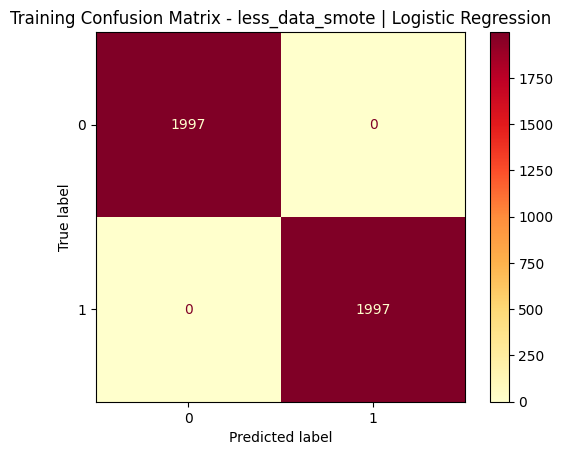

less_data_smote | Decision Tree - Training
TN=1997, FP=0, FN=0, TP=1997


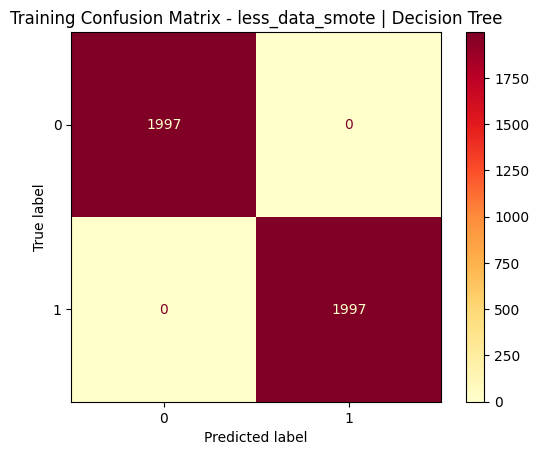

less_data_smote | Random Forest - Training
TN=1997, FP=0, FN=0, TP=1997


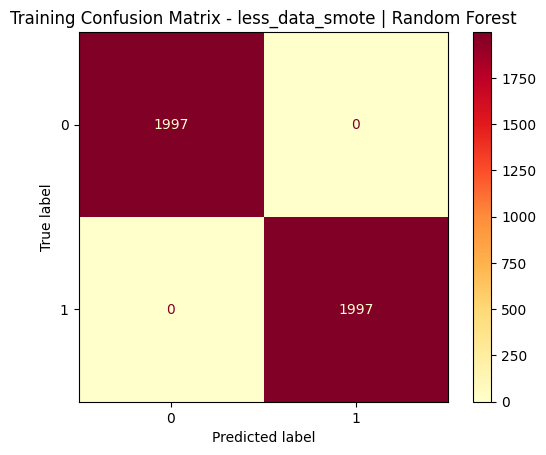

less_data_smote | ANN - Training
TN=1988, FP=9, FN=0, TP=1997


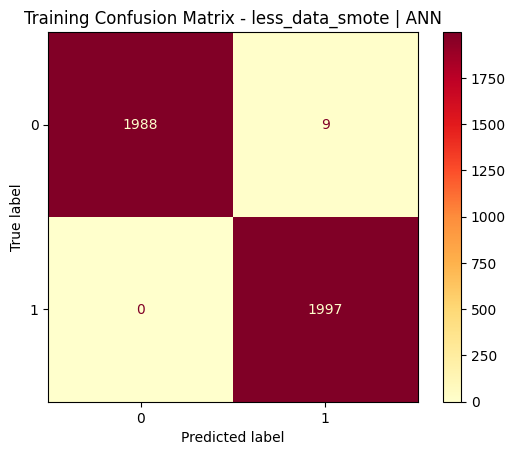

ratio_1_to_1 | Logistic Regression - Training
TN=389, FP=4, FN=30, TP=364


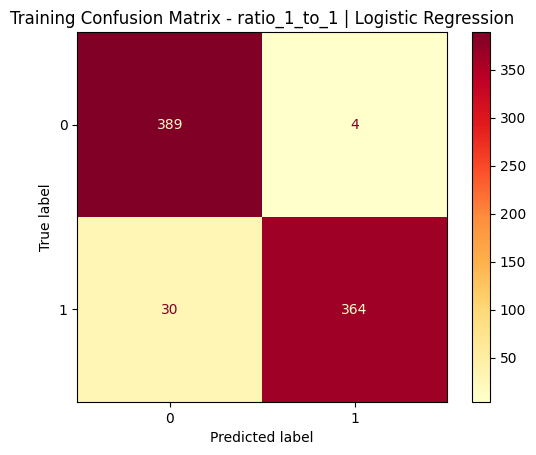

ratio_1_to_1 | Decision Tree - Training
TN=384, FP=9, FN=24, TP=370


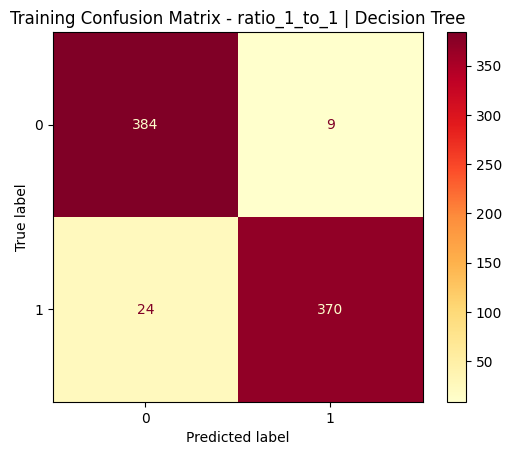

ratio_1_to_1 | Random Forest - Training
TN=393, FP=0, FN=9, TP=385


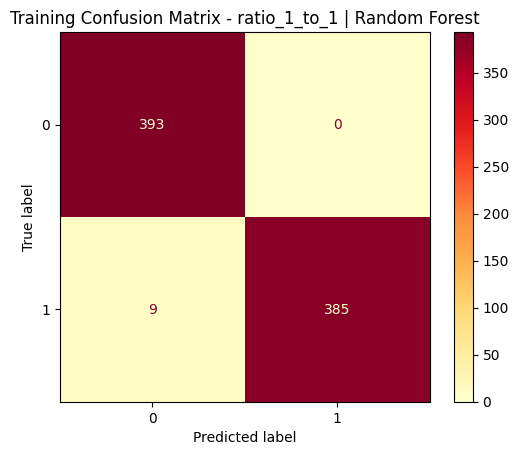

ratio_1_to_1 | ANN - Training
TN=391, FP=2, FN=49, TP=345


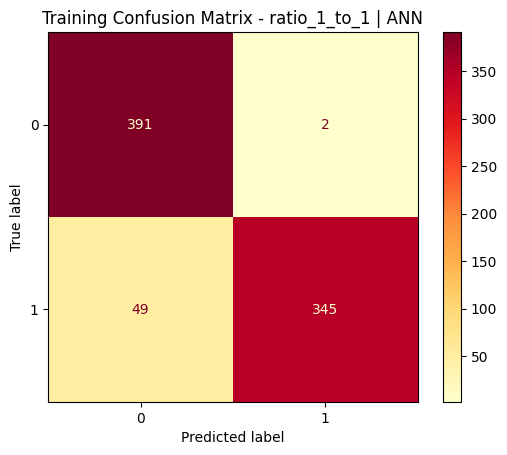


=== Test Confusion Matrices ===
less_data_smote | Logistic Regression - Test
TN=399, FP=0, FN=0, TP=1


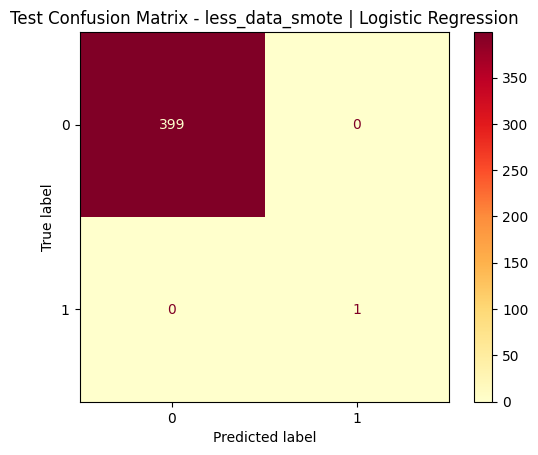

less_data_smote | Decision Tree - Test
TN=399, FP=0, FN=1, TP=0


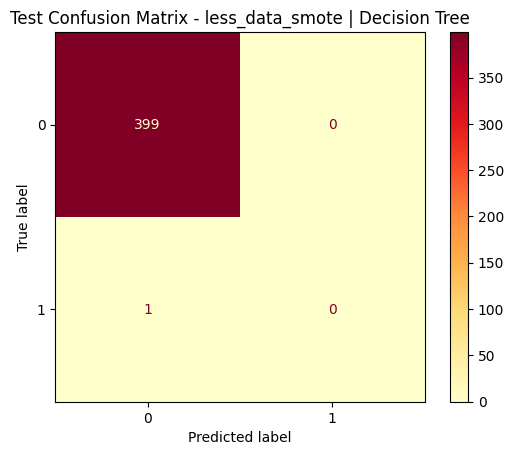

less_data_smote | Random Forest - Test
TN=399, FP=0, FN=1, TP=0


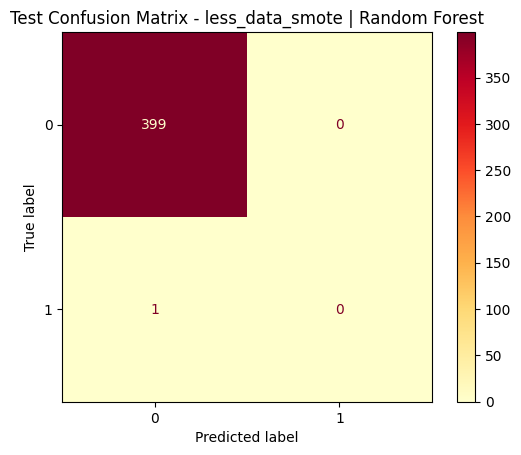

less_data_smote | ANN - Test
TN=398, FP=1, FN=0, TP=1


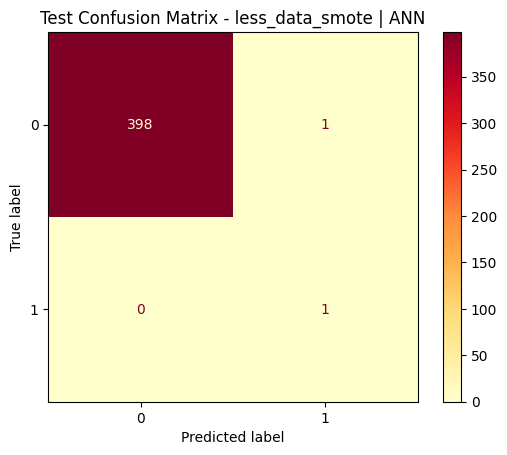

ratio_1_to_1 | Logistic Regression - Test
TN=94, FP=5, FN=9, TP=89


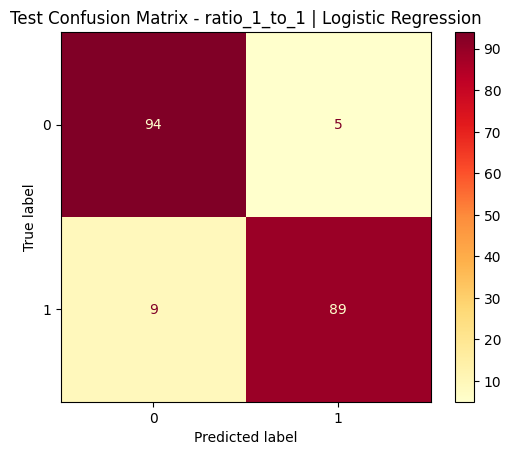

ratio_1_to_1 | Decision Tree - Test
TN=95, FP=4, FN=10, TP=88


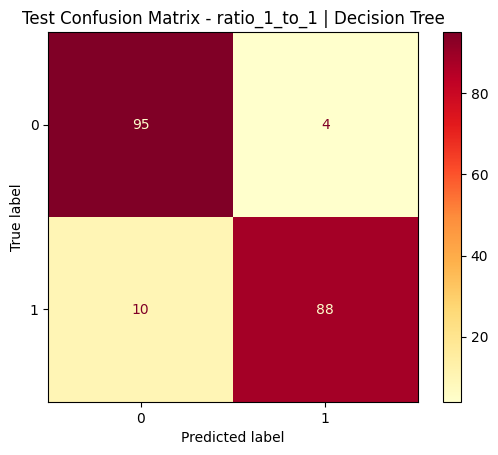

ratio_1_to_1 | Random Forest - Test
TN=95, FP=4, FN=8, TP=90


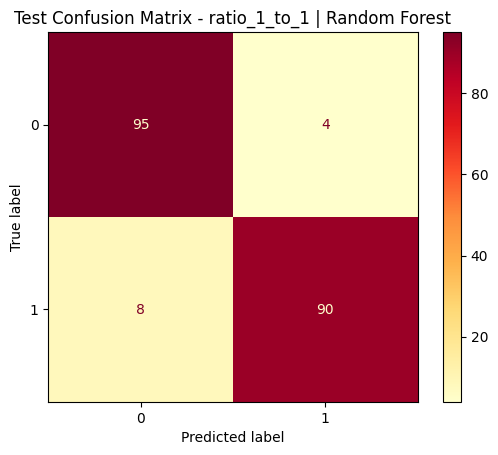

ratio_1_to_1 | ANN - Test
TN=98, FP=1, FN=14, TP=84


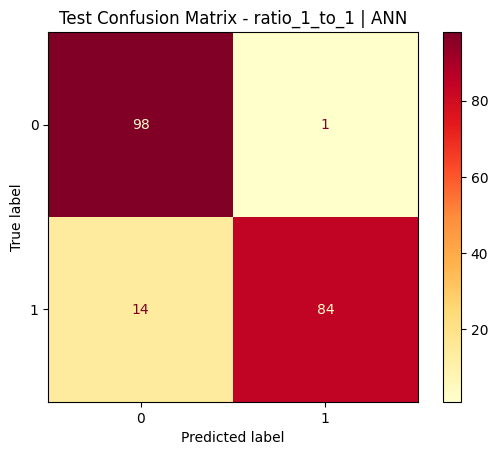

In [69]:
# Clean Driver & Logging (underscore function names, readable variables)
logs = []
modelPredictions = {}

def to_label_predictions(trainedModel, XData):
    yPred = np.asarray(trainedModel.predict(XData)).ravel()
    if np.issubdtype(yPred.dtype, np.floating):
        yPred = np.round(yPred)
    return yPred.astype(int)

def evaluate_model(trainedModel, modelName, datasetName, XTrain, XTest, YTrain, YTest, bestParams=None):
    yTrainPred = to_label_predictions(trainedModel, XTrain)
    yTestPred = to_label_predictions(trainedModel, XTest)
    yTrainTrue = np.asarray(YTrain).ravel().astype(int)
    yTestTrue = np.asarray(YTest).ravel().astype(int)

    modelKey = f"{datasetName} | {modelName}"
    modelPredictions[modelKey] = {'y_train_true': yTrainTrue,'y_train_pred': yTrainPred,'y_test_true': yTestTrue,'y_test_pred': yTestPred}

    result = [0 for _ in range(13)]
    result[0] = accuracy_score(yTrainTrue, yTrainPred)
    result[1] = accuracy_score(yTestTrue, yTestPred)
    result[2] = precision_score(yTrainTrue, yTrainPred, zero_division=0)
    result[3] = precision_score(yTestTrue, yTestPred, zero_division=0)
    result[4] = recall_score(yTrainTrue, yTrainPred)
    result[5] = recall_score(yTestTrue, yTestPred)
    result[6] = f1_score(yTrainTrue, yTrainPred)
    result[7] = f1_score(yTestTrue, yTestPred)
    result[8] = roc_auc_score(yTrainTrue, yTrainPred)
    result[9] = roc_auc_score(yTestTrue, yTestPred)
    result[10] = modelName
    result[11] = str(bestParams) if bestParams is not None else "N/A"
    result[12] = datasetName
    logs.append(result)

def run_models_for_dataset(datasetName, XTrain, XTest, YTrain, YTest, cvFolds=3, runAnn=True):
    print(f"\n=== Dataset: {datasetName} ===")
    print("Train shape:", XTrain.shape, "Test shape:", XTest.shape)
    print("Train class distribution:", pd.Series(YTrain).value_counts().to_dict())

    modelTrainers = [("Logistic Regression", train_logistic_regression),("Decision Tree", train_decision_tree),("Random Forest", train_random_forest)]
    if runAnn:
        modelTrainers.append(("ANN", train_ann))

    for modelName, trainer in modelTrainers:
        trainedModel, bestParams, bestScore = trainer(XTrain, YTrain, cvFolds=cvFolds)
        print(f"{modelName} best CV score: {bestScore:.5f} | params: {bestParams}")
        evaluate_model(trainedModel, modelName, datasetName, XTrain, XTest, YTrain, YTest, bestParams=bestParams)

def run_dataset_comparison(cvFolds=3, runAnn=True, sampleRows=20000, testRatio=0.2, selectedDatasets=None):
    logs.clear()
    modelPredictions.clear()

    datasetBuilders = {
        "original_data": lambda: build_original_split(X, Y, testRatio=testRatio),
        "less_data": lambda: build_original_small_unbalanced_split(X, Y, sampleRows=sampleRows, testRatio=testRatio),
        "less_data_smote": lambda: build_smote_small_split(X, Y, sampleRows=sampleRows, testRatio=testRatio),
        "ratio_1_to_1": lambda: build_undersampled_split(credit_card_data, testRatio=testRatio),
    }

    datasetsToRun = selectedDatasets if selectedDatasets is not None else list(datasetBuilders.keys())
    for datasetName in datasetsToRun:
        if datasetName not in datasetBuilders:
            raise ValueError(f"Unknown dataset name: {datasetName}. Valid options are: {list(datasetBuilders.keys())}")

        builder = datasetBuilders[datasetName]
        XTrainDs, XTestDs, YTrainDs, YTestDs = builder()
        run_models_for_dataset(datasetName, XTrainDs, XTestDs, YTrainDs, YTestDs, cvFolds=cvFolds, runAnn=runAnn)

def driver(cvFolds=3, runAnn=True, sampleRows=20000, testRatio=0.2, selectedDatasets=None):
    datasetMenu = {
        "1": "original_data",
        "2": "less_data",
        "3": "less_data_smote",
        "4": "ratio_1_to_1",
    }
    availableDatasets = list(datasetMenu.values())
    isInteractiveSelection = selectedDatasets is None

    if isInteractiveSelection:
        userText = input(
            "Choose dataset numbers (space-separated) or press Enter for all:\n"
            "1) original_data\n"
            "2) less_data\n"
            "3) less_data_smote\n"
            "4) ratio_1_to_1\n"
            "Your choice: "
        ).strip()

        if userText == "" or userText.lower() == "all":
            selectedDatasets = availableDatasets
        else:
            selectedDatasets = []
            seenDatasets = set()
            for token in userText.split():
                if token not in datasetMenu:
                    raise ValueError("Use only 1, 2, 3, 4 (space-separated), or press Enter for all.")
                datasetName = datasetMenu[token]
                if datasetName not in seenDatasets:
                    selectedDatasets.append(datasetName)
                    seenDatasets.add(datasetName)

    needsSampleRows = ("less_data" in selectedDatasets) or ("less_data_smote" in selectedDatasets)
    if isInteractiveSelection and needsSampleRows:
        rowsText = input(f"Enter number of entries for less-data datasets (current {sampleRows}): ").strip()
        if rowsText != "":
            if not rowsText.isdigit() or int(rowsText) <= 0:
                raise ValueError("Please enter a positive integer for sample rows.")
            sampleRows = int(rowsText)

    run_dataset_comparison(cvFolds=cvFolds, runAnn=runAnn, sampleRows=sampleRows, testRatio=testRatio, selectedDatasets=selectedDatasets)
    scoreNames, trainingData, testData = [], [], []
    experimentName, paramsCol, datasetCol = [], [], []

    for result in logs:
        scoreNames.extend(["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
        trainingData.extend([f"{result[i]:.5f}" for i in range(0, 10, 2)])
        testData.extend([f"{result[i]:.5f}" for i in range(1, 10, 2)])
        experimentName.extend([result[10]] + [""] * 4)
        paramsCol.extend([result[11]] + [""] * 4)
        datasetCol.extend([result[12]] + [""] * 4)

    rows = [[datasetCol[i], experimentName[i], paramsCol[i], scoreNames[i], trainingData[i], testData[i]] for i in range(len(trainingData))]
    header = ["Dataset", "Experiment Name", "Best Params", "Score", "Training Data", "Test Data"]
    print(tabulate(rows, headers=header, tablefmt="fancy_grid"))

    print("\n=== Training Confusion Matrices ===")
    for modelName, preds in modelPredictions.items():
        tn, fp, fn, tp = confusion_matrix(preds['y_train_true'], preds['y_train_pred']).ravel()
        print(f"{modelName} - Training")
        print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
        confTrain = ConfusionMatrixDisplay.from_predictions(preds['y_train_true'], preds['y_train_pred'], cmap='YlOrRd', colorbar=True, values_format='d')
        confTrain.ax_.set_title(f"Training Confusion Matrix - {modelName}")
        confTrain.ax_.grid(False)
        plt.show()

    print("\n=== Test Confusion Matrices ===")
    for modelName, preds in modelPredictions.items():
        tn, fp, fn, tp = confusion_matrix(preds['y_test_true'], preds['y_test_pred']).ravel()
        print(f"{modelName} - Test")
        print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")
        confTest = ConfusionMatrixDisplay.from_predictions(preds['y_test_true'], preds['y_test_pred'], cmap='YlOrRd', colorbar=True, values_format='d')
        confTest.ax_.set_title(f"Test Confusion Matrix - {modelName}")
        confTest.ax_.grid(False)
        plt.show()
driver()